<a href="https://colab.research.google.com/github/Nirbhay-kr24/Document-Classification-Using-Deep-Learning/blob/main/Document_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# # Document Classification Using Deep Learning

## Course Project

### Objective
To automatically classify news articles into one of four categories:
- World
- Sports
- Business
- Science/Technology

### Dataset
AG News Dataset

### Models Implemented
1. MLP + TF-IDF
2. Vanilla LSTM
3. Bidirectional LSTM

### Frameworks Used
- PyTorch
- Scikit-Learn
- NumPy
- Pandas
- Matplotlib
- Hugging Face Datasets
- Seaborn

# 1. Problem Statement

Modern news platforms publish thousands of articles every day. Organizing these articles manually is inefficient, time-consuming, and susceptible to human error. As the volume of digital information continues to grow, automated document classification systems have become essential for information management and content recommendation.

The primary goal of this project is to design and evaluate Deep Learning models capable of automatically classifying news articles into one of four predefined categories. The study compares traditional feature-based approaches with sequence-learning neural networks to determine which architecture provides the most effective performance for document classification tasks.

### Expected Outcomes
Develop an automated news classification system.
Compare the performance of MLP, LSTM, and BiLSTM models.
Evaluate model performance using accuracy and classification metrics.

# 2. Theoretical Foundations

This project uses different Deep Learning techniques to classify news articles into predefined categories.

## TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF is a feature extraction technique that converts text into numerical vectors. It assigns higher importance to informative words and lower importance to commonly occurring words.

## Multi-Layer Perceptron (MLP)

A Multi-Layer Perceptron is a feedforward neural network consisting of input, hidden, and output layers. In this project, TF-IDF vectors are used as inputs to the MLP model for document classification.

## Long Short-Term Memory (LSTM)

LSTM is a type of Recurrent Neural Network (RNN) designed to process sequential data. It can learn contextual information from text and capture long-term dependencies between words.

## Bidirectional LSTM (BiLSTM)

BiLSTM processes text in both forward and backward directions, allowing the model to understand context from both past and future words within a sentence.

# 3: Environment Setup & Dependency Installation

In [1]:
!pip install datasets

# 4. Library Imports

In [2]:
import os
import time
import random
import string
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

## 4.1: Device Configuration

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using Device: {device}")

Using Device: cuda


# 5. Dataset Loading and Preparation

The AG News dataset is loaded from the Hugging Face Datasets library. The dataset is divided into training, validation, and testing subsets for model development and evaluation.

To ensure compatibility with PyTorch's CrossEntropyLoss function, class labels are normalized to a zero-based indexing scheme ranging from 0 to 3.

### News Categories

| Label | Category |
| ----- | -------- |
| 0     | World    |
| 1     | Sports   |
| 2     | Business |
| 3     | Sci/Tech |


In [4]:
print("Loading AG News dataset from Hugging Face...")
raw_datasets = load_dataset("sh0416/ag_news")
existing_columns = raw_datasets['train'].column_names

# Dynamically map and clean text column variations
if 'text' not in existing_columns:
    if 'description' in existing_columns:
        raw_datasets = raw_datasets.rename_column('description', 'text')
    elif 'Title' in existing_columns and 'Description' in existing_columns:
        raw_datasets = raw_datasets.map(lambda x: {'text': f"{x['Title']} {x['Description']}"})

# Scaled Dataset Splits
TRAIN_SIZE = 100000
VAL_SIZE = 20000

train_texts = raw_datasets['train']['text'][:TRAIN_SIZE]
train_labels = raw_datasets['train']['label'][:TRAIN_SIZE]

val_texts = raw_datasets['train']['text'][TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
val_labels = raw_datasets['train']['label'][TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]

test_texts = raw_datasets['test']['text']
test_labels = raw_datasets['test']['label']

# Explicitly normalize label ranges for PyTorch CrossEntropyLoss (0 to 3)
min_lbl, max_lbl = min(train_labels), max(train_labels)
if min_lbl == 1 or max_lbl == 4:
    print("Labels are 1-indexed. Shifting down to 0-3 index framework...")
    train_labels = [L - 1 for L in train_labels]
    val_labels = [L - 1 for L in val_labels]
    test_labels = [L - 1 for L in test_labels]

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
print(f"Data Splits Configured! Train size: {len(train_texts)} | Val size: {len(val_texts)} | Test size: {len(test_texts)}")

Loading AG News dataset from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Labels are 1-indexed. Shifting down to 0-3 index framework...
Data Splits Configured! Train size: 100000 | Val size: 20000 | Test size: 7600


# 6. TF-IDF Feature Extraction and Data Preparation for MLP

In [5]:
print("Generating TF-IDF matrices for Experiment 1...")
tfidf_vectorizer = TfidfVectorizer(max_features=4000, stop_words='english')

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts).toarray()
X_val_tfidf = tfidf_vectorizer.transform(val_texts).toarray()
X_test_tfidf = tfidf_vectorizer.transform(test_texts).toarray()

# Create Tensor Datasets
mlp_train_ds = TensorDataset(torch.tensor(X_train_tfidf, dtype=torch.float32), torch.tensor(train_labels, dtype=torch.long))
mlp_val_ds = TensorDataset(torch.tensor(X_val_tfidf, dtype=torch.float32), torch.tensor(val_labels, dtype=torch.long))
mlp_test_ds = TensorDataset(torch.tensor(X_test_tfidf, dtype=torch.float32), torch.tensor(test_labels, dtype=torch.long))

# Instantiate DataLoaders
mlp_train_loader = DataLoader(mlp_train_ds, batch_size=64, shuffle=True)
mlp_val_loader = DataLoader(mlp_val_ds, batch_size=64, shuffle=False)
mlp_test_loader = DataLoader(mlp_test_ds, batch_size=64, shuffle=False)
print("MLP Data Pipelines initialized successfully.")

Generating TF-IDF matrices for Experiment 1...
MLP Data Pipelines initialized successfully.


- TF-IDF STATISTICS

In [6]:
print("=" * 20)
print("TF-IDF STATISTICS")
print("=" * 20)

print(f"Number of Features: {X_train_tfidf.shape[1]}")
print(f"Training Matrix Shape: {X_train_tfidf.shape}")
print(f"Validation Matrix Shape: {X_val_tfidf.shape}")
print(f"Testing Matrix Shape: {X_test_tfidf.shape}")

TF-IDF STATISTICS
Number of Features: 4000
Training Matrix Shape: (100000, 4000)
Validation Matrix Shape: (20000, 4000)
Testing Matrix Shape: (7600, 4000)


# 7. Text Tokenization and Sequence Preparation for LSTM Models

In [7]:
print("Building explicit word dictionary tokenizers for LSTMs...")

def clean_tokenize(text):
    text = text.lower()
    for punct in string.punctuation:
        text = text.replace(punct, " ")
    return text.split()

# Tabulate word occurrences across your training matrix
word_counts = Counter()
for text in train_texts:
    word_counts.update(clean_tokenize(text))

# Build Vocabulary Index Lookup Table
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, freq in word_counts.most_common(20000): # Top 20k tokens
    if freq >= 2:
        vocab[word] = len(vocab)

def text_to_sequence(text, vocab, max_len=80):
    tokens = clean_tokenize(text)
    seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    if len(seq) < max_len:
        seq += [vocab["<PAD>"]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

X_train_seq = np.array([text_to_sequence(t, vocab) for t in train_texts])
X_val_seq = np.array([text_to_sequence(t, vocab) for t in val_texts])
X_test_seq = np.array([text_to_sequence(t, vocab) for t in test_texts])

lstm_train_ds = TensorDataset(torch.tensor(X_train_seq, dtype=torch.long), torch.tensor(train_labels, dtype=torch.long))
lstm_val_ds = TensorDataset(torch.tensor(X_val_seq, dtype=torch.long), torch.tensor(val_labels, dtype=torch.long))
lstm_test_ds = TensorDataset(torch.tensor(X_test_seq, dtype=torch.long), torch.tensor(test_labels, dtype=torch.long))

lstm_train_loader = DataLoader(lstm_train_ds, batch_size=64, shuffle=True)
lstm_val_loader = DataLoader(lstm_val_ds, batch_size=64, shuffle=False)
lstm_test_loader = DataLoader(lstm_test_ds, batch_size=64, shuffle=False)
print(f"Vocabulary Size: {len(vocab)}")

Building explicit word dictionary tokenizers for LSTMs...
Vocabulary Size: 20002


- VOCABULARY STATISTICS

In [8]:
print("=" * 20)
print("VOCABULARY STATISTICS")
print("=" * 20)

print(f"Vocabulary Size: {len(vocab)}")
print(f"Maximum Sequence Length: 80")
print(f"Training Sequences Shape: {X_train_seq.shape}")
print(f"Validation Sequences Shape: {X_val_seq.shape}")
print(f"Testing Sequences Shape: {X_test_seq.shape}")

VOCABULARY STATISTICS
Vocabulary Size: 20002
Maximum Sequence Length: 80
Training Sequences Shape: (100000, 80)
Validation Sequences Shape: (20000, 80)
Testing Sequences Shape: (7600, 80)


# 8. Multi-Layer Perceptron (MLP) Architecture

In [9]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_classes=4):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    def forward(self, x):
        return self.network(x)

# 9. Vanilla LSTM Architecture

In [10]:
class VanillaLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        out, (h_n, c_n) = self.lstm(embedded)
        last_hidden = h_n[-1, :, :]
        return self.fc(self.dropout(last_hidden))

# 10. Bidirectional LSTM (BiLSTM) Architecture

In [11]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        out, (h_n, c_n) = self.lstm(embedded)
        combined_hidden = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        return self.fc(self.dropout(combined_hidden))

# 11. Model Architecture Statistics

In [12]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print("=" * 20)
print("MODEL PARAMETERS")
print("=" * 20)

print(
    f"MLP Parameters      : {count_parameters(MLPClassifier(4000)):,}"
)

print(
    f"Vanilla LSTM Params : {count_parameters(VanillaLSTMClassifier(len(vocab))):,}"
)

print(
    f"BiLSTM Parameters   : {count_parameters(BiLSTMClassifier(len(vocab))):,}"
)

MODEL PARAMETERS
MLP Parameters      : 1,057,668
Vanilla LSTM Params : 2,692,868
BiLSTM Parameters   : 2,825,476


- ### Observation

The BiLSTM model contains the highest number of trainable parameters, while the MLP model is the most computationally efficient.

# 12. Early Stopping Strategy

In [13]:
class EarlyStopping:
    def __init__(self, patience=2, min_delta=0.002):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# 13. Model Training Framework
## Training Configuration

- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 64
- Maximum Epochs: 10

In [14]:
def train_engine(model, train_loader, val_loader, epochs=10, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    early_stopping = EarlyStopping()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += targets.size(0)
            correct_train += predicted.eq(targets).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_train / total_train

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total_val += targets.size(0)
                correct_val += predicted.eq(targets).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_acc = correct_val / total_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {val_acc:.4f}")

        early_stopping(epoch_val_loss)
        if early_stopping.early_stop:
            print("Early stopping rules triggered. Halting optimization loop.")
            break

    return history, time.time() - start_time

# 14. Model Evaluation Framework

In [15]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.numpy())
    return np.array(all_targets), np.array(all_preds)

# 15. Experiment 1: MLP + TF-IDF

In [16]:
print("\n--- Running Experiment 1: MLP + TF-IDF ---")
mlp_model = MLPClassifier(input_dim=4000)
mlp_history, mlp_time = train_engine(mlp_model, mlp_train_loader, mlp_val_loader)


--- Running Experiment 1: MLP + TF-IDF ---
Epoch 01 | Train Loss: 0.3777 Acc: 0.8732 | Val Loss: 0.3101 Acc: 0.8886
Epoch 02 | Train Loss: 0.2681 Acc: 0.9081 | Val Loss: 0.3140 Acc: 0.8878
Epoch 03 | Train Loss: 0.2280 Acc: 0.9218 | Val Loss: 0.3210 Acc: 0.8866
Early stopping rules triggered. Halting optimization loop.


# 16. Experiment 2: Vanilla LSTM

In [17]:
print("\n--- Running Experiment 2: Vanilla LSTM ---")
lstm_model = VanillaLSTMClassifier(vocab_size=len(vocab))
lstm_history, lstm_time = train_engine(lstm_model, lstm_train_loader, lstm_val_loader)


--- Running Experiment 2: Vanilla LSTM ---
Epoch 01 | Train Loss: 1.3883 Acc: 0.2550 | Val Loss: 1.3903 Acc: 0.2448
Epoch 02 | Train Loss: 1.3064 Acc: 0.3236 | Val Loss: 1.1638 Acc: 0.4345
Epoch 03 | Train Loss: 0.9376 Acc: 0.5599 | Val Loss: 0.8588 Acc: 0.5786
Epoch 04 | Train Loss: 0.6808 Acc: 0.6921 | Val Loss: 0.5825 Acc: 0.7750
Epoch 05 | Train Loss: 0.3528 Acc: 0.8836 | Val Loss: 0.3185 Acc: 0.8907
Epoch 06 | Train Loss: 0.2451 Acc: 0.9225 | Val Loss: 0.3013 Acc: 0.8956
Epoch 07 | Train Loss: 0.2048 Acc: 0.9348 | Val Loss: 0.3106 Acc: 0.8966
Epoch 08 | Train Loss: 0.1797 Acc: 0.9433 | Val Loss: 0.3295 Acc: 0.8906
Early stopping rules triggered. Halting optimization loop.


# 17. Experiment 3: Bidirectional LSTM

In [18]:
print("\n--- Running Experiment 3: Bidirectional LSTM ---")
bilstm_model = BiLSTMClassifier(vocab_size=len(vocab))
bilstm_history, bilstm_time = train_engine(bilstm_model, lstm_train_loader, lstm_val_loader)


--- Running Experiment 3: Bidirectional LSTM ---
Epoch 01 | Train Loss: 0.6286 Acc: 0.7563 | Val Loss: 0.4226 Acc: 0.8563
Epoch 02 | Train Loss: 0.3453 Acc: 0.8802 | Val Loss: 0.3303 Acc: 0.8831
Epoch 03 | Train Loss: 0.2826 Acc: 0.9029 | Val Loss: 0.3006 Acc: 0.8978
Epoch 04 | Train Loss: 0.2455 Acc: 0.9149 | Val Loss: 0.3033 Acc: 0.8944
Epoch 05 | Train Loss: 0.2173 Acc: 0.9248 | Val Loss: 0.2923 Acc: 0.9009
Epoch 06 | Train Loss: 0.1941 Acc: 0.9322 | Val Loss: 0.3016 Acc: 0.9016
Epoch 07 | Train Loss: 0.1740 Acc: 0.9391 | Val Loss: 0.3112 Acc: 0.9031
Early stopping rules triggered. Halting optimization loop.


# 18. Model Evaluation

In [19]:
mlp_targets, mlp_preds = evaluate_model(mlp_model, mlp_test_loader)
lstm_targets, lstm_preds = evaluate_model(lstm_model, lstm_test_loader)
bilstm_targets, bilstm_preds = evaluate_model(bilstm_model, lstm_test_loader)
print("\nAll experiments finalized.")


All experiments finalized.


# 19. Model Performance Comparison

In [20]:
mlp_acc = np.mean(mlp_preds == test_labels)
lstm_acc = np.mean(lstm_preds == test_labels)
bilstm_acc = np.mean(bilstm_preds == test_labels)


results = pd.DataFrame({
    "Model": [
        "MLP + TF-IDF",
        "Vanilla LSTM",
        "Bidirectional LSTM"
    ],
    "Accuracy": [
        mlp_acc,
        lstm_acc,
        bilstm_acc
    ],
    "Training Time (sec)": [
        mlp_time,
        lstm_time,
        bilstm_time
    ]
})

print("="*60)
print("               SUMMARY EXPERIMENT BENCHMARKS")
print("="*60)
print(results.to_string(index=False))
print("="*60)

               SUMMARY EXPERIMENT BENCHMARKS
             Model  Accuracy  Training Time (sec)
      MLP + TF-IDF  0.892895            16.050856
      Vanilla LSTM  0.901974            57.773252
Bidirectional LSTM  0.907895            79.319414


## 19.1 Model Performance (Accuracy) Visualization

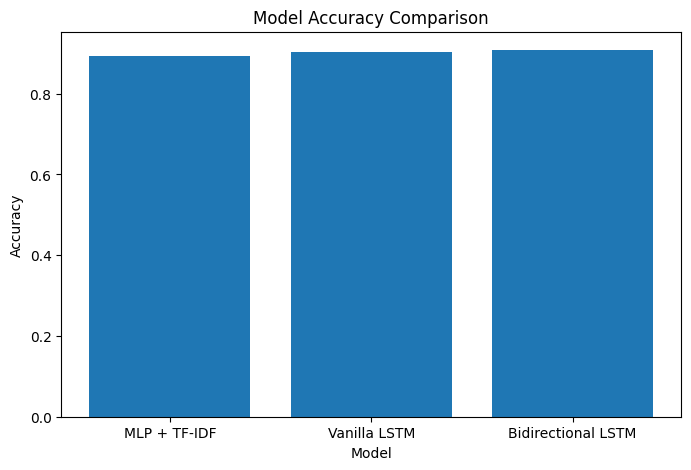

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

# 20. Classification Report

In [22]:
print("\n--- Detailed Summary Classification Report (BiLSTM) ---")
print(classification_report(test_labels, bilstm_preds, target_names=class_names))


--- Detailed Summary Classification Report (BiLSTM) ---
              precision    recall  f1-score   support

       World       0.93      0.90      0.91      1900
      Sports       0.94      0.98      0.96      1900
    Business       0.88      0.87      0.88      1900
    Sci/Tech       0.88      0.88      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



# 21. Per-Class Performance Analysis

In [23]:
cm = confusion_matrix(test_labels, bilstm_preds)

print()
print("PER-CLASS ACCURACY BREAKDOWN")
print()
for i, cls in enumerate(class_names):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"{cls:<12}: {class_acc:.4f}")


PER-CLASS ACCURACY BREAKDOWN

World       : 0.8984
Sports      : 0.9805
Business    : 0.8716
Sci/Tech    : 0.8811


# 22. Training Performance Visualization

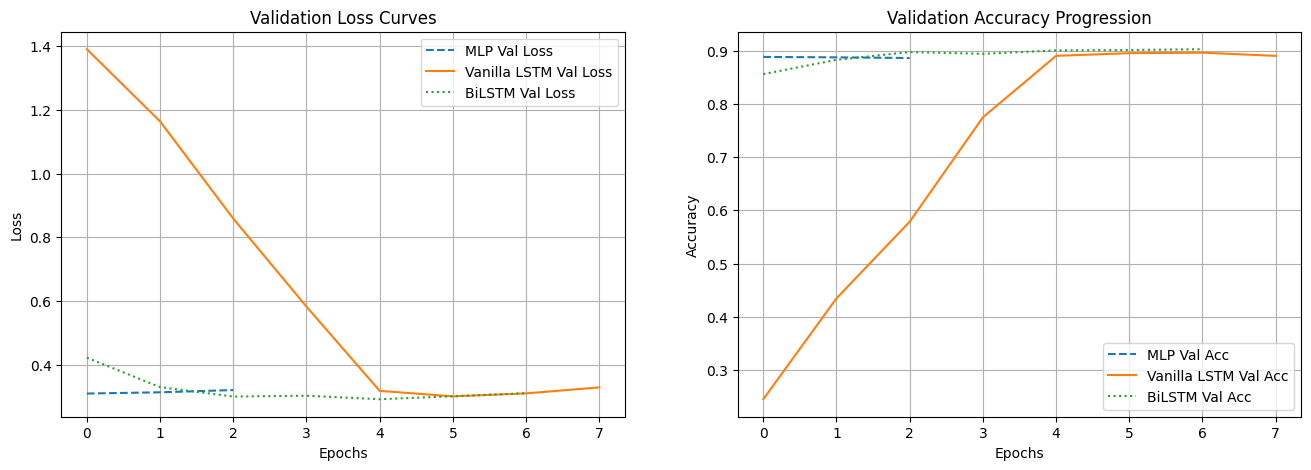

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(mlp_history['val_loss'], label='MLP Val Loss', linestyle='--')
axes[0].plot(lstm_history['val_loss'], label='Vanilla LSTM Val Loss')
axes[0].plot(bilstm_history['val_loss'], label='BiLSTM Val Loss', linestyle=':')
axes[0].set_title('Validation Loss Curves')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mlp_history['val_acc'], label='MLP Val Acc', linestyle='--')
axes[1].plot(lstm_history['val_acc'], label='Vanilla LSTM Val Acc')
axes[1].plot(bilstm_history['val_acc'], label='BiLSTM Val Acc', linestyle=':')
axes[1].set_title('Validation Accuracy Progression')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)
plt.show()

# 23. Confusion Matrix Analysis

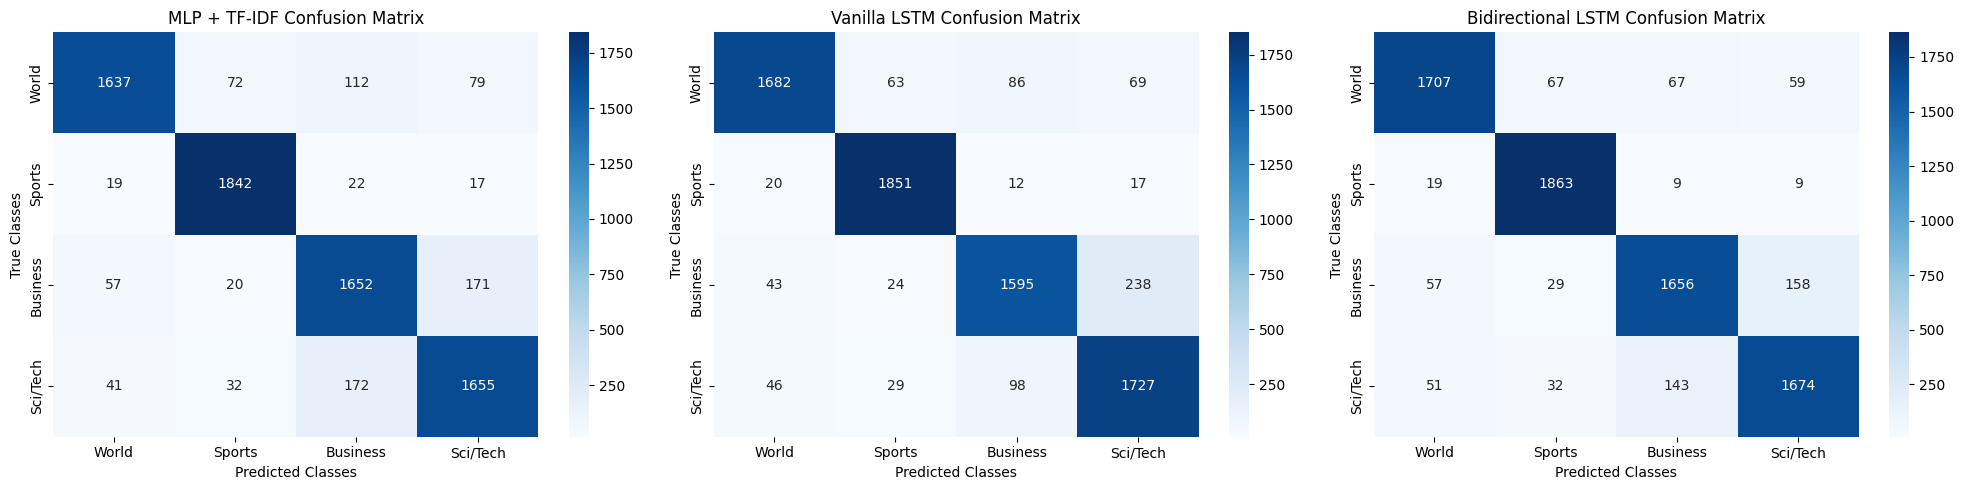

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
models_preds = [mlp_preds, lstm_preds, bilstm_preds]
titles = ['MLP + TF-IDF Confusion Matrix', 'Vanilla LSTM Confusion Matrix', 'Bidirectional LSTM Confusion Matrix']

for idx, (preds, title) in enumerate(zip(models_preds, titles)):
    matrix = confusion_matrix(test_labels, preds)
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Predicted Classes')
    axes[idx].set_ylabel('True Classes')

plt.tight_layout()
plt.show()

# 24. Real-Time News Classification

In [26]:
def predict_news(text, model):

    seq = text_to_sequence(text, vocab)
    seq = torch.tensor([seq], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        output = model(seq)
        pred = torch.argmax(output, dim=1).item()

    return class_names[pred]

print("\n--- Sample News Classification Predictions ---")
print(
    f"Headline 1: 'Apple launches a new AI powered iPhone' -> Prediction: {predict_news('Apple launches a new AI powered iPhone', bilstm_model)}"
    )
print(
    f"Headline 2: 'Manchester United wins the football championship' -> Prediction: {predict_news('Manchester United wins the football championship', bilstm_model)}"
    )
print(
    f"Headline 3: 'Stock market falls after weak earnings reports' -> Prediction: {predict_news('Stock market falls after weak earnings reports', bilstm_model)}"
    )
print(
    f"Headline 4: 'United Nations discusses global climate policies during summit' -> Prediction: {predict_news('United Nations discusses global climate policies during summit', bilstm_model)}"
)

print(
    f"Headline 5: 'NASA successfully launches next-generation space telescope' -> Prediction: {predict_news('NASA successfully launches next-generation space telescope', bilstm_model)}"
)


--- Sample News Classification Predictions ---
Headline 1: 'Apple launches a new AI powered iPhone' -> Prediction: Sci/Tech
Headline 2: 'Manchester United wins the football championship' -> Prediction: Sports
Headline 3: 'Stock market falls after weak earnings reports' -> Prediction: Business
Headline 4: 'United Nations discusses global climate policies during summit' -> Prediction: World
Headline 5: 'NASA successfully launches next-generation space telescope' -> Prediction: Sci/Tech


## 24.1 User Input Prediction

In [28]:
'''while True:

    text = input(
        "\nEnter a News Headline (type 'exit' to quit): "
    )

    if text.lower() == "exit":
        break

    prediction = predict_news(
        text,
        bilstm_model
    )

    print(
        f"Predicted Category: {prediction}"
    )'''

'while True:\n\n    text = input(\n        "\nEnter a News Headline (type \'exit\' to quit): "\n    )\n\n    if text.lower() == "exit":\n        break\n\n    prediction = predict_news(\n        text,\n        bilstm_model\n    )\n\n    print(\n        f"Predicted Category: {prediction}"\n    )'

# 25. Conclusion

This project successfully developed an automated news article classification system using the AG News dataset.

Three models were implemented and evaluated:

• MLP + TF-IDF
• Vanilla LSTM
• Bidirectional LSTM (BiLSTM)

Experimental results showed that the BiLSTM achieved the highest accuracy of 90.61%, outperforming both the MLP and Vanilla LSTM models. The MLP model also delivered competitive performance while requiring fewer trainable parameters and lower computational resources.

Overall, the BiLSTM proved to be the most effective model for news document classification in this study.